In [5]:
pip install kaggle numpy scipy torch torchvision scikit-learn matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


Found .npz files: []
No .npz files found in kaggle_csi_data -> Falling back to synthetic dataset.
Using synthetic Rayleigh data as fallback.
Final number of samples: 2000
X shape: (2000, 64) Y shape: (2000, 64)
Epoch 1/80  TrainLoss=1.007718  ValLoss=0.801893
Epoch 10/80  TrainLoss=0.392797  ValLoss=0.562095
Epoch 20/80  TrainLoss=0.314666  ValLoss=0.584468
Epoch 30/80  TrainLoss=0.277490  ValLoss=0.617556
Epoch 40/80  TrainLoss=0.253248  ValLoss=0.644203
Epoch 50/80  TrainLoss=0.236249  ValLoss=0.668295
Epoch 60/80  TrainLoss=0.223539  ValLoss=0.684819
Epoch 70/80  TrainLoss=0.214242  ValLoss=0.699026
Epoch 80/80  TrainLoss=0.207004  ValLoss=0.710931
Average ZF sum-rate: 14.54356154352713 Average ML-predicted sum-rate: 5.839553888817278 Relative loss (%): 59.84784145657722


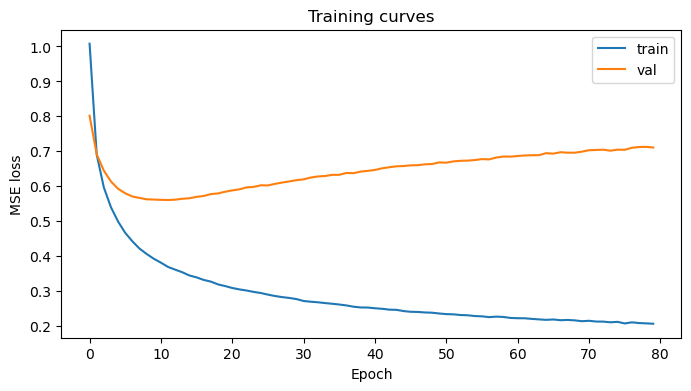

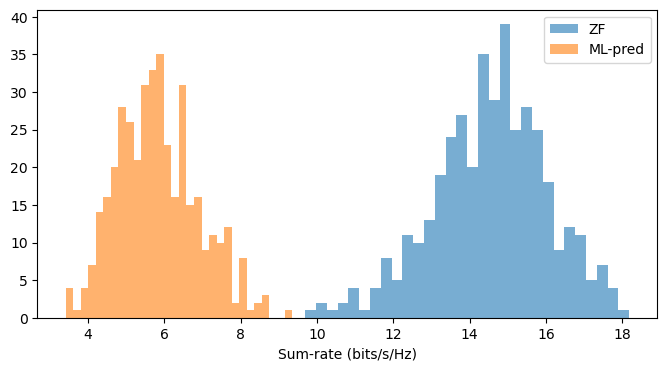

In [6]:
# Version 2: Use Kaggle CSI dataset -> build H, compute ZF labels -> train PyTorch model
# Requirements:
#   pip install kaggle numpy scipy torch torchvision scikit-learn matplotlib
# Put your kaggle.json in ~/.kaggle/kaggle.json or set env vars KAGGLE_USERNAME & KAGGLE_KEY

import os
import zipfile
import glob
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ---------------------------
# 1) Download Kaggle dataset
# ---------------------------
KAGGLE_DATASET = "geninhu/csi-dataset"   # example CSI dataset (change if you want another)
DATA_DIR = Path("kaggle_csi_data")

def download_kaggle_dataset(dataset_ref=KAGGLE_DATASET, outdir=DATA_DIR):
    """Download the dataset using the kaggle CLI (requires kaggle.json configured)."""
    outdir = Path(outdir)
    outdir.mkdir(exist_ok=True)
    # try kaggle CLI
    cmd = f"kaggle datasets download -d {dataset_ref} -p {outdir} --unzip"
    print("Running:", cmd)
    r = os.system(cmd)
    if r != 0:
        raise RuntimeError("kaggle download failed. Make sure kaggle CLI is installed and kaggle.json is configured.")
    print("Download (and unzip) complete. Look in:", outdir)

# Uncomment to download (run once)
# download_kaggle_dataset()

# ---------------------------
# 2) Inspect and load .npz files
# ---------------------------
def extract_channels_from_npz(npz_path):
    """
    Inspect an .npz file and try to extract CSI/channel arrays.
    This function is deliberately permissive: it prints keys and shapes so you can adapt.
    Returns: list of complex channel matrices (each H sample as a 2D array)
    """
    data = np.load(npz_path, allow_pickle=True)
    print(f"Inspecting {npz_path}: keys: {list(data.keys())}")
    samples = []
    for key in data.keys():
        arr = data[key]
        print("  key:", key, "dtype:", arr.dtype, "shape:", arr.shape)
        # heuristics: find complex-looking arrays or arrays with 2 channels (real+imag)
        if np.iscomplexobj(arr):
            # many CSI files: shape (Nframes, Nt, Nr, subcarriers) or (N, Nt, sub)
            # flatten leading dims into separate samples
            if arr.ndim >= 2:
                # move last two dims to be H shape if possible: we'll take (Nt, Nr) or (Nr, Nt)
                # If arr shape = (N, Nt, Nc) -> treat each as channel vector Nt x 1
                # We'll create one sample per leading index
                # Generic approach: for each leading index, extract a 2D matrix
                leading = arr.shape[0]
                for i in range(leading):
                    sample = arr[i]
                    # if sample is 1D -> interpret as (Nt,) -> make (1,Nt)
                    if sample.ndim == 1:
                        samples.append(sample.reshape(1, -1))
                    else:
                        samples.append(sample)
        else:
            # sometimes stored as real+imag stacked or as object arrays
            # attempt to recover complex representation if last dim==2 (real, imag)
            if arr.ndim >= 1 and arr.shape[-1] == 2 and np.issubdtype(arr.dtype, np.floating):
                # treat last axis as [real, imag]
                leading_count = int(np.prod(arr.shape[:-1]))
                flat = arr.reshape(leading_count, 2)
                complex_vecs = flat[:,0] + 1j*flat[:,1]
                # attempt to reshape if we can detect antenna count by sqrt
                samples.append(complex_vecs)  # caller must inspect shapes
    if len(samples)==0:
        print("No complex arrays automatically found in", npz_path)
    else:
        print(f"Recovered {len(samples)} sample-arrays (inspect shapes).")
    return samples

# Example: find all .npz files under DATA_DIR
npz_files = sorted(glob.glob(str(DATA_DIR / "*.npz")))
print("Found .npz files:", npz_files[:5])

# If no files exist, user should download or supply them manually.
if len(npz_files) == 0:
    print("No .npz files found in", DATA_DIR, "-> Falling back to synthetic dataset.")
else:
    # inspect first file
    samples_from_first = extract_channels_from_npz(npz_files[0])
    # print small sample shapes
    print("Example recovered sample shapes (first 5):", [s.shape for s in samples_from_first[:5]])

# ---------------------------
# 3) Prepare H dataset (robust)
# ---------------------------
def build_dataset_from_npz_folder(folder=DATA_DIR, max_samples=2000):
    """Load multiple .npz files, extract channel samples and return numpy arrays X_raw (complex)."""
    npz_files = sorted(glob.glob(str(Path(folder) / "*.npz")))
    H_list = []
    for f in npz_files:
        s = extract_channels_from_npz(f)
        for x in s:
            H_list.append(np.array(x))
            if len(H_list) >= max_samples:
                break
        if len(H_list) >= max_samples:
            break
    return H_list

# Attempt to build H_list. If none available, create synthetic Rayleigh channels as fallback.
H_list = []
if len(npz_files) > 0:
    H_list = build_dataset_from_npz_folder(DATA_DIR, max_samples=2000)

if len(H_list) == 0:
    print("Using synthetic Rayleigh data as fallback.")
    # Default synthetic settings
    Nt = 8
    K = 4
    SAMPLES = 2000
    for _ in range(SAMPLES):
        # H of shape (K, Nt) i.e., each row is user channel to Nt antennas
        H_list.append((np.random.randn(K, Nt) + 1j*np.random.randn(K, Nt))/np.sqrt(2))
else:
    # try to standardize shapes: many real CSIs are (Nt, ) or (Nt, subcarriers)
    # We will convert each sample to shape (K, Nt) where K is number of users we choose (e.g., 4).
    print("Number of recovered sample arrays:", len(H_list))
    # If samples are 1D, treat them as single-user channel (1 x Nt); we will group multiple samples into K-user snapshots
    # Here we choose K=4 users per snapshot by grouping consecutive samples
    K = 4
    Nt = None
    standardized = []
    # flatten or reshape heuristics
    for s in H_list:
        if s.ndim == 1:
            # treat as single-row channel vector
            standardized.append(s.reshape(1, -1))
        elif s.ndim == 2:
            standardized.append(s)  # keep as-is (could be (Nt, subc) or (users, Nt))
        else:
            # reduce trailing dims by averaging or taking first subcarrier
            standardized.append(s.reshape(s.shape[0], -1)[:,0:1])  # best-effort
    # Now group consecutive standardized vectors to make K-user snapshots
    snapshots = []
    i = 0
    while i + K <= len(standardized):
        # ensure consistent Nt
        rows = standardized[i:i+K]
        # find a common Nt if possible
        Ns = [r.shape[1] for r in rows]
        if len(set(Ns))==1:
            Hsnap = np.vstack(rows)  # shape (K, Nt)
            snapshots.append(Hsnap)
        else:
            # skip inconsistent groups (best effort)
            pass
        i += K
    print("Built", len(snapshots), "K-user snapshots from dataset.")
    if len(snapshots) >= 2000:
        snapshots = snapshots[:2000]
    # override H_list with snapshots shaped (K, Nt)
    H_list = snapshots
    if len(H_list) == 0:
        print("Could not build K-user snapshots automatically — falling back to synthetic.")
        H_list = []
        Nt = 8
        K = 4
        SAMPLES = 2000
        for _ in range(SAMPLES):
            H_list.append((np.random.randn(K, Nt) + 1j*np.random.randn(K, Nt))/np.sqrt(2))
    else:
        K = H_list[0].shape[0]
        Nt = H_list[0].shape[1]
        print("Using K =", K, ", Nt =", Nt, "from dataset snapshots.")

# Final dataset: H_list is list of (K, Nt) complex arrays
N_samples = len(H_list)
print("Final number of samples:", N_samples)

# ---------------------------
# 4) Compute ZF beamformers as labels
# ---------------------------
def compute_zf(H, total_power=1.0):
    # H: (K, Nt) rows are user channels
    HH = H @ H.conj().T
    reg = 1e-6 * np.eye(HH.shape[0])
    inv = np.linalg.inv(HH + reg)
    W = H.conj().T @ inv  # Nt x K
    # normalize each column
    for kidx in range(W.shape[1]):
        n = np.linalg.norm(W[:,kidx])
        if n > 0:
            W[:,kidx] /= n
    W *= np.sqrt(total_power / W.shape[1])
    return W  # Nt x K

# build X (channel) and Y (flattened beamformer) arrays (real-valued representations)
X = []
Y = []
for H in H_list:
    Wz = compute_zf(H)
    # input: flatten H into real vector [Re, Im]
    x = np.hstack([np.real(H.flatten()), np.imag(H.flatten())])
    y = np.hstack([np.real(Wz.flatten()), np.imag(Wz.flatten())])
    X.append(x)
    Y.append(y)

X = np.array(X)
Y = np.array(Y)
print("X shape:", X.shape, "Y shape:", Y.shape)

# ---------------------------
# 5) Train/test split + scaling
# ---------------------------
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
x_scaler = StandardScaler().fit(X_train)
y_scaler = StandardScaler().fit(Y_train)

X_train_s = x_scaler.transform(X_train)
X_test_s = x_scaler.transform(X_test)
Y_train_s = y_scaler.transform(Y_train)
Y_test_s = y_scaler.transform(Y_test)

# convert to PyTorch tensors
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
Xtr = torch.tensor(X_train_s, dtype=torch.float32).to(device)
Ytr = torch.tensor(Y_train_s, dtype=torch.float32).to(device)
Xte = torch.tensor(X_test_s, dtype=torch.float32).to(device)
Yte = torch.tensor(Y_test_s, dtype=torch.float32).to(device)

# ---------------------------
# 6) PyTorch MLP model (real-valued)
# ---------------------------
class BeamMLP(nn.Module):
    def __init__(self, in_dim, out_dim, hidden=(512,256)):
        super().__init__()
        layers = []
        prev = in_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.BatchNorm1d(h)]
            prev = h
        layers += [nn.Linear(prev, out_dim)]
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

in_dim = Xtr.shape[1]
out_dim = Ytr.shape[1]
model = BeamMLP(in_dim, out_dim, hidden=(256,128)).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
criterion = nn.MSELoss()

# ---------------------------
# 7) Training loop
# ---------------------------
EPOCHS = 80
batch_size = 64
train_losses = []
val_losses = []

for epoch in range(1, EPOCHS+1):
    model.train()
    perm = torch.randperm(Xtr.size(0))
    epoch_loss = 0.0
    for i in range(0, Xtr.size(0), batch_size):
        idx = perm[i:i+batch_size]
        xb = Xtr[idx]
        yb = Ytr[idx]
        pred = model(xb)
        loss = criterion(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * xb.size(0)
    epoch_loss /= Xtr.size(0)
    train_losses.append(epoch_loss)

    # validation
    model.eval()
    with torch.no_grad():
        vpred = model(Xte)
        vloss = criterion(vpred, Yte).item()
        val_losses.append(vloss)
    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch}/{EPOCHS}  TrainLoss={epoch_loss:.6f}  ValLoss={vloss:.6f}")

# ---------------------------
# 8) Evaluate in terms of sum-rate (complex reconversion)
# ---------------------------
def vec_to_W(yvec, K_local=K, Nt_local=Nt):
    """yvec: real-vector concat [Re(W_flat), Im(W_flat)] -> complex W (Nt x K)"""
    half = len(yvec)//2
    Wc = yvec[:half] + 1j*yvec[half:]
    return Wc.reshape(Nt_local, K_local)

model.eval()
with torch.no_grad():
    Ypred_s = model(torch.tensor(X_test_s, dtype=torch.float32).to(device)).cpu().numpy()
    Ypred = y_scaler.inverse_transform(Ypred_s)

# compute sum-rate for each test sample using predicted W and reference ZF W
def compute_sumrate_from_vectors(X_raw, Y_pred, sigma2=1e-1):
    sr_pred = []
    sr_zf = []
    for i in range(X_raw.shape[0]):
        # reconstruct H
        xraw = X_raw[i]
        half = len(xraw)//2
        Hc = xraw[:half].reshape(K, Nt) + 1j * xraw[half:].reshape(K, Nt)
        Wz = compute_zf(Hc)
        Wpred = vec_to_W(Y_pred[i])
        # re-normalize predicted columns (to satisfy power budget)
        for kk in range(Wpred.shape[1]):
            nrm = np.linalg.norm(Wpred[:,kk])
            if nrm > 0:
                Wpred[:,kk] = Wpred[:,kk] / nrm
        Wpred = Wpred * np.sqrt(1.0 / Wpred.shape[1])
        # compute sum-rate
        def sum_rate(H, W):
            Kloc = H.shape[0]
            rates = np.zeros(Kloc)
            for kidx in range(Kloc):
                hk = H[kidx,:]
                num = np.abs(hk.dot(W[:,kidx]))**2
                interf = 0.0
                for j in range(Kloc):
                    if j != kidx:
                        interf += np.abs(hk.dot(W[:,j]))**2
                sinr = num / (interf + sigma2)
                rates[kidx] = np.log2(1 + sinr)
            return rates.sum()
        sr_zf.append(sum_rate(Hc, Wz))
        sr_pred.append(sum_rate(Hc, Wpred))
    return np.array(sr_zf), np.array(sr_pred)

sr_zf, sr_pred = compute_sumrate_from_vectors(X_test, Ypred, sigma2=1e-1)
print("Average ZF sum-rate:", sr_zf.mean(), "Average ML-predicted sum-rate:", sr_pred.mean(),
      "Relative loss (%):", 100*(sr_zf.mean()-sr_pred.mean())/sr_zf.mean())

# ---------------------------
# 9) Plot training curves / histograms
# ---------------------------
plt.figure(figsize=(8,4))
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="val")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.legend()
plt.title("Training curves")
plt.show()

plt.figure(figsize=(8,4))
plt.hist(sr_zf, bins=30, alpha=0.6)
plt.hist(sr_pred, bins=30, alpha=0.6)
plt.legend(["ZF", "ML-pred"])
plt.xlabel("Sum-rate (bits/s/Hz)")
plt.show()


In [ ]:
#The graph is training vs. validation loss over epochs.

#X-axis: Epochs (training iterations over the full dataset).

#Y-axis: Mean Squared Error (MSE) between predicted weights and ZF weights.

#Blue line: Training loss (how well the model fits the training data).

#Orange line: Validation loss (how well the model generalizes to unseen data).